In [3]:
import importlib
import os
from omegaconf import OmegaConf
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
import scripts.generate_training_data
importlib.reload(scripts.generate_training_data)
from scripts.generate_training_data import main, gif_that

cfg = OmegaConf.load(f'..\\config\\default.yaml')
q_traj1 = main(cfg)

2026-09-19 13:40:38,748 INFO scripts.generate_training_data: Requested device: cpu, using device: CPU


2026-09-19 13:40:39,334 INFO scripts.generate_training_data: Fine timestep is 1e+03s and coarsened timestep is 1.6e+04s. Model spinup for 0.00 eddy turnover times (~0 high-res steps). Training horizon is 2000 low-res steps (~370.37 days). Validation plotting window is 10000 steps (~1851.85 days).


tau_eddy: 0.2478720247745514
Spinup time in model units: 0.0
model hr dt: 1.1945012753036847e-05
Spinup in steps: 0

=== trajectory diagnostics ===
U_rms = 0.0120171
beta = 88.8264
epsilon (model units) = 5.21174e-05
L_R = sqrt(U_rms / beta) = 0.0116313
L_beta = (epsilon / beta^3)^(1/5) = 0.00942478
R_beta = L_beta / L_R = 0.810293


2026-09-17 20:05:14,224 WARNING matplotlib.animation: MovieWriter ffmpeg unavailable; using Pillow instead.


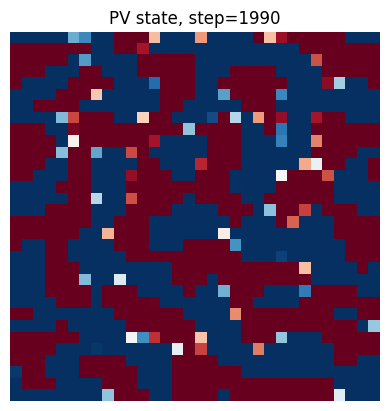

In [ ]:
q_traj3 = q_traj1[1:]
out_file= os.path.join(cfg.filepaths.out_dir, "plot.gif")
gif_that(q_traj1, out_file=out_file, cadence=10)

In [4]:
# Scale audit and inverse design for L_beta / L_Rhines.
# The measured U_rms should be preferred; the drag-balance value is only a closure estimate.
import math
import numpy as np


def scale_audit(params, target_ratio=2.5, measured_u_rms=None, r_eff=None):
    beta_dim = float(params["beta"])
    ly_dim = float(params.get("Ly", params["Lx"]))
    n_jets = float(params["n_jets"])
    epsilon_dim = float(params["epsilon"])
    drag_dim = float(params["drag"])
    u1_dim = float(params.get("U1", 0.0))
    u2_dim = float(params.get("U2", 0.0))

    length_scale = ly_dim / (math.pi * n_jets)
    velocity_scale = beta_dim * length_scale**2 / (math.pi * n_jets)**2
    time_scale = length_scale / velocity_scale

    epsilon_nd = epsilon_dim * length_scale / velocity_scale**3
    drag_nd = drag_dim * time_scale
    u1_nd = u1_dim / velocity_scale
    u2_nd = u2_dim / velocity_scale
    beta_nd = (math.pi * n_jets)**2

    result = {
        "length_scale_m": length_scale,
        "velocity_scale_m_per_s": velocity_scale,
        "time_scale_days": time_scale / 86400.0,
        "beta_nondim": beta_nd,
        "epsilon_nondim": epsilon_nd,
        "drag_nondim": drag_nd,
        "U1_nondim": u1_nd,
        "U2_nondim": u2_nd,
        "epsilon_sensitivity": {
            "beta": "epsilon_nd scales as beta_dim^(-3) when L_y and n_jets are fixed",
            "L_y": "epsilon_nd scales as L_y^(-5) when beta_dim and n_jets are fixed",
            "n_jets": "epsilon_nd scales as n_jets^(11) when beta_dim and L_y are fixed",
            "epsilon_dim": "linear",
        },
    }

    if measured_u_rms is not None:
        u = float(measured_u_rms)
        result["measured_U_rms"] = u
        result["measured_L_Rhines"] = math.sqrt(u / beta_nd)
        result["epsilon_nd_for_target_ratio"] = target_ratio**5 * math.sqrt(beta_nd) * u**2.5
        result["epsilon_dim_for_target_ratio"] = (
            result["epsilon_nd_for_target_ratio"] * velocity_scale**3 / length_scale
        )

    if r_eff is None:
        r_eff = drag_nd
    result["r_eff_nondim"] = float(r_eff)
    result["U_rms_from_drag_balance"] = math.sqrt(epsilon_nd / r_eff) if r_eff > 0 else math.inf
    u_balance = result["U_rms_from_drag_balance"]
    result["ratio_from_drag_balance"] = epsilon_nd**0.2 * beta_nd**-0.1 * u_balance**-0.5
    result["epsilon_nd_for_target_ratio_from_balance"] = (
        r_eff**5 / (target_ratio**20 * beta_nd**2)
    )
    result["epsilon_dim_for_target_ratio_from_balance"] = (
        result["epsilon_nd_for_target_ratio_from_balance"] * velocity_scale**3 / length_scale
    )
    return result


params_for_audit = dict(OmegaConf.to_container(cfg.params, resolve=True))
params_for_audit["dt"] = float(cfg.plotting.dt)

audit_model = QGM(params_for_audit)
audit_state = audit_model.initialise(
    jax.random.PRNGKey(int(params_for_audit["seed"])),
    n_jets=int(params_for_audit["n_jets"]),
    pseudo=True,
)
_, measured_u_rms = audit_model.rhines_length(audit_state)

audit = scale_audit(
    params_for_audit,
    target_ratio=2.5,
    measured_u_rms=float(measured_u_rms),
)
for key, value in audit.items():
    print(f"{key}: {value}")

print("\nRecommended interpretation:")
print("- epsilon_nd is an energy-input rate in the nondimensional model.")
print("- U_rms_from_drag_balance assumes injection ~= r_eff * U_rms^2.")
print("- Because friction acts only on the bottom layer here, r_eff is not exactly drag.")
print("- Use a long trajectory average of U_rms before changing epsilon for a target ratio.")

length_scale_m: 106103.29539459689
velocity_scale_m_per_s: 0.0012674052166276957
time_scale_days: 968.9461462593695
beta_nondim: 88.82643960980423
epsilon_nondim: 0.000521173591720208
drag_nondim: 0.041858473518404764
U1_nondim: 7.890136373754197
U2_nondim: 0.0
epsilon_sensitivity: {'beta': 'epsilon_nd scales as beta_dim^(-3) when L_y and n_jets are fixed', 'L_y': 'epsilon_nd scales as L_y^(-5) when beta_dim and n_jets are fixed', 'n_jets': 'epsilon_nd scales as n_jets^(11) when beta_dim and L_y are fixed', 'epsilon_dim': 'linear'}
measured_U_rms: 0.12177050113677979
measured_L_Rhines: 0.037025413656477095
epsilon_nd_for_target_ratio: 4.762405862255375
epsilon_dim_for_target_ratio: 9.137849534041764e-14
r_eff_nondim: 0.041858473518404764
U_rms_from_drag_balance: 0.11158337868736456
ratio_from_drag_balance: 0.4214465481280992
epsilon_nd_for_target_ratio_from_balance: 1.7907388255817214e-19
epsilon_dim_for_target_ratio_from_balance: 3.435973836800004e-33

Recommended interpretation:
- ep